In [1]:
import bigfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
from nbodykit.lab import BigFileCatalog
from scipy.spatial import distance

# Import class to analyze MP_Gadget run snapshots
from dm_snapshot_analysis import SnapshotData

In [2]:
## RUN IF YOU WANT OLD RUN WITH NGRID=128
# Snapshot imports to obtain DM particle attributes
snapshot000 = '/home/aschann/MP-Gadget-Original-Backup/DM_Halos_March10/output/PART_000'
snapshot001 = '/home/aschann/MP-Gadget-Original-Backup/DM_Halos_March10/output/PART_001'
snapshot002 = '/home/aschann/MP-Gadget-Original-Backup/DM_Halos_March10/output/PART_002'
snapshot003 = '/home/aschann/MP-Gadget-Original-Backup/DM_Halos_March10/output/PART_003'
snapshot004 = '/home/aschann/MP-Gadget-Original-Backup/DM_Halos_March10/output/PART_004'
snapshot005 = '/home/aschann/MP-Gadget-Original-Backup/DM_Halos_March10/output/PART_005'
snapshot006 = '/home/aschann/MP-Gadget-Original-Backup/DM_Halos_March10/output/PART_006'

# Import class to obtain data from snapshot 
snap0 = SnapshotData(snapshot000)
snap1 = SnapshotData(snapshot001)
snap2 = SnapshotData(snapshot002)
snap3 = SnapshotData(snapshot003)
snap4 = SnapshotData(snapshot004)
snap5 = SnapshotData(snapshot005)
snap6 = SnapshotData(snapshot006)

/home/aschann/miniconda/envs/test/lib/python3.6/site-packages/bigfile/__init__.py:358: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  return pyxbigfile.Dataset.__init__(self, file, dtype=dtype, size=size)


In [ ]:
# Snapshot imports to obtain DM particle attributes
snapshot000 = '/home/aschann/MP-Gadget/DM_Halos_April_7/output/PART_000'
snapshot001 = '/home/aschann/MP-Gadget/DM_Halos_April_7/output/PART_001'
snapshot002 = '/home/aschann/MP-Gadget/DM_Halos_April_7/output/PART_002'
snapshot003 = '/home/aschann/MP-Gadget/DM_Halos_April_7/output/PART_003'
snapshot004 = '/home/aschann/MP-Gadget/DM_Halos_April_7/output/PART_004'
snapshot005 = '/home/aschann/MP-Gadget/DM_Halos_April_7/output/PART_005'
snapshot006 = '/home/aschann/MP-Gadget/DM_Halos_April_7/output/PART_006'

# Import class to obtain data from snapshot 
snap0 = SnapshotData(snapshot000)
snap1 = SnapshotData(snapshot001)
snap2 = SnapshotData(snapshot002)
snap3 = SnapshotData(snapshot003)
snap4 = SnapshotData(snapshot004)
snap5 = SnapshotData(snapshot005)
snap6 = SnapshotData(snapshot006)

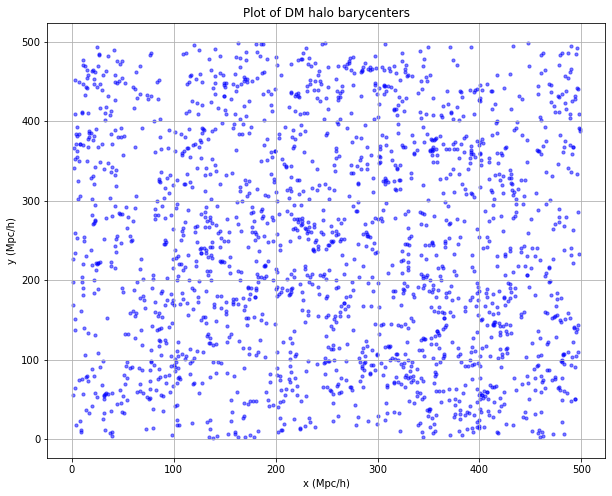

In [3]:
# Retrieve and plot barycenters of halos
barycenters = snap6.calculate_barycenters()

snap6.plot_2D_barycenters()

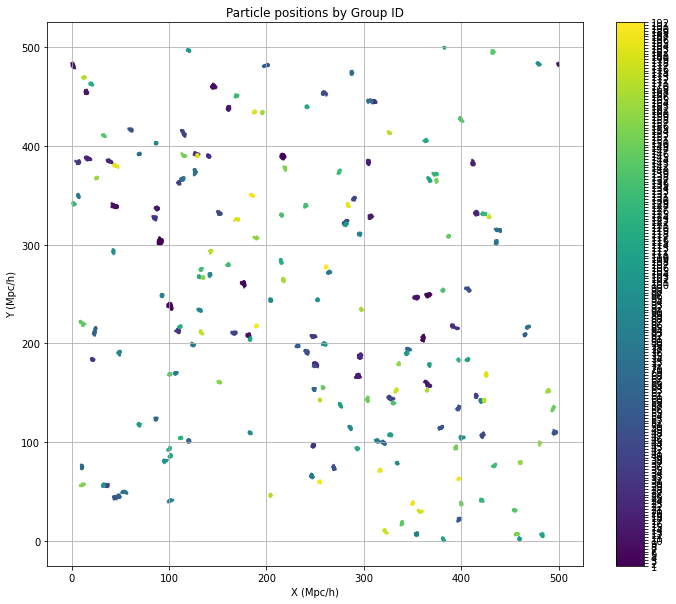

In [4]:
# Filter particles by group ID, then plot particles for those groups 
target_ids, target_counts = snap6.get_significant_groups(sigma=1)

# returns dictionary of particles with target IDs
target_particles = snap6.filter_particles_by_group(target_ids=target_ids) 

# Plot in 2D
snap6.plot_particle_groups(target_ids=target_ids)

# After deciding on groups of interest, isolate and study them below

Closest group IDs to specified points:  [41, 9]


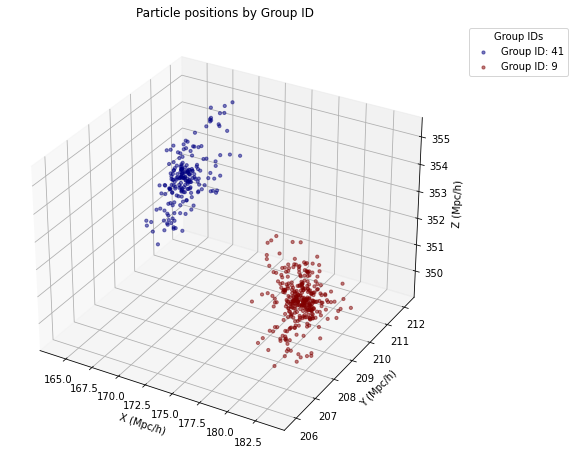

In [5]:
# Find group ID related to particles near a point of interest
points_of_interest = [(167, 209), (182,206)] # indicate points you want to search near as a tuple

# Get list of groups associated to the points we give
target_groups = snap6.find_closest_groups(points_of_interest=points_of_interest)
print("Closest group IDs to specified points: ", target_groups)

# Plot two halos of interest
snap6.plot_3D_particle_groups(target_ids=target_groups, legend=True)

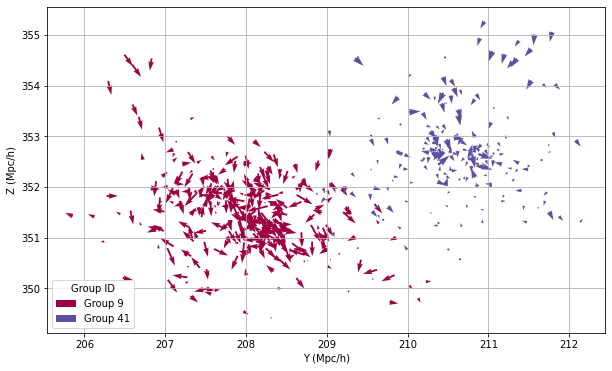

In [6]:
# Plot group velocities -- currently convert from Unit Velocity (cm/sec) to km/s
snap6.plot_group_velocities(target_groups,scale=0.9)

In [7]:
# Angular momentum calculations
Lg1 = snap6.calculate_angular_momentum((46,8))
Lg1 # group 1's angular momenta

{8: array([-5.48908104e+31, -5.57577734e+31, -1.41734385e+32]),
 46: array([1.16155144e+31, 6.57811141e+31, 2.87256191e+31])}

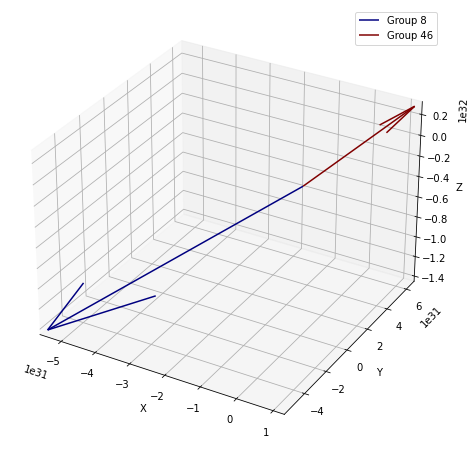

In [8]:
# Plot angular momenta
snap6.plot_angular_momenta(Lg1)

In [20]:
# Convert L from g*cm**2/s to g*Mpc**2/s

conversion_factor = (1/ 3.085678e24)**2  # Converts from cm**2 to Mpc**2
Lg1_mpc = {}

for group_id, L_cm in Lg1.items():
    # Convert each component of angular momentum vector
    L_mpc = L_cm * conversion_factor
    Lg1_mpc[group_id] = L_mpc

Lg1_mpc

{8: array([-1.86830523e-42, -1.89781384e-42, -4.82417898e-42]),
 46: array([3.95354455e-43, 2.23897587e-42, 9.77726947e-43])}

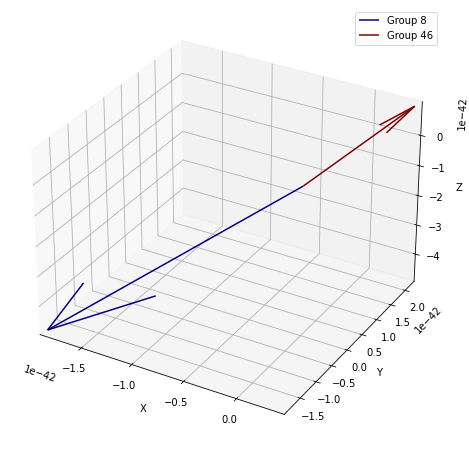

In [21]:
# Plot angular momenta
snap6.plot_angular_momenta(Lg1_mpc)

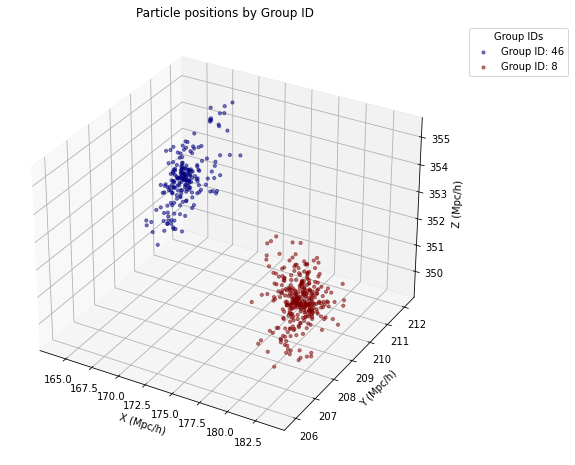

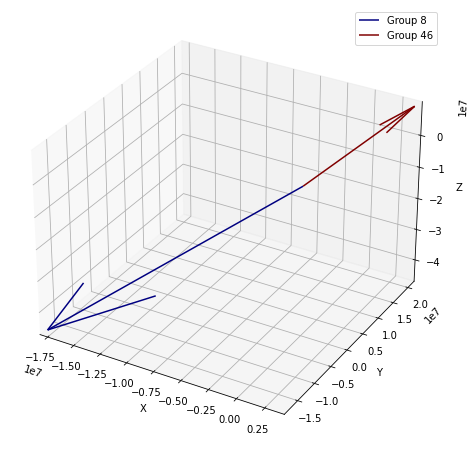

In [10]:
# Plot halos and angular momentua

# Plot two halos of interest
snap6.plot_3D_particle_groups(target_ids=target_groups, legend=True)

# Plot angular momenta
snap6.plot_angular_momenta(Lg1)

In [ ]:
# Plot halos and angular momentua


### Let's look at another group

Closest group IDs to specified points:  [183, 306]


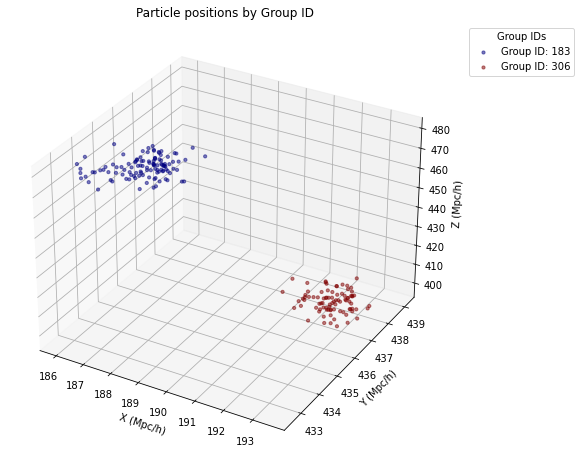

In [12]:
# Find group ID related to particles near a point of interest
points_of_interest = [(185, 440), (195,440)] # indicate points you want to search near as a tuple

# Get list of groups associated to the points we give
target_groups = snap6.find_closest_groups(points_of_interest=points_of_interest)
print("Closest group IDs to specified points: ", target_groups)

# Plot two halos of interest
snap6.plot_3D_particle_groups(target_ids=target_groups, legend=True)

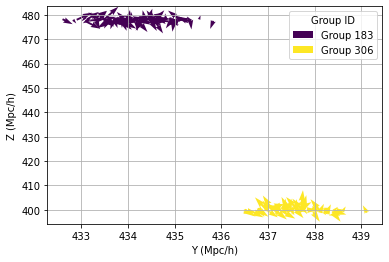

In [20]:
# Plot group velocities
snap6.plot_group_velocities(target_groups,scale=30000)

{183: array([-1142025.53881017, -2528814.48290633,  -595661.64232516]), 306: array([  96924.08826339, 2614551.23739645, 3257797.36897337])}


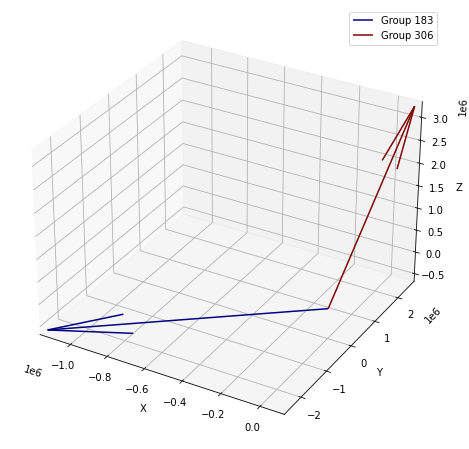

In [14]:
# Angular momentum calculations
Lg2 = snap6.calculate_angular_momentum((183,306))
print(Lg2 )

# Plot angular momenta
snap6.plot_angular_momenta(Lg2)

### Group pair 3

Closest group IDs to specified points:  [1564, 1917]


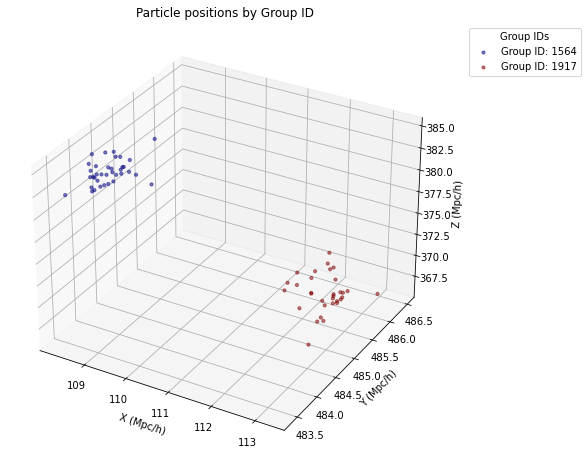

In [21]:
# Find group ID related to particles near a point of interest
points_of_interest = [(108, 482), (112,483)] # indicate points you want to search near as a tuple

# Get list of groups associated to the points we give
target_groups = snap6.find_closest_groups(points_of_interest=points_of_interest)
print("Closest group IDs to specified points: ", target_groups)

# Plot two halos of interest
snap6.plot_3D_particle_groups(target_ids=target_groups, legend=True)

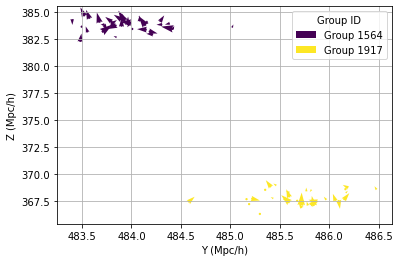

In [28]:
# Plot group velocities
snap6.plot_group_velocities(target_groups,scale=30000)

{1564: array([ 369681.92514019, -592096.55231095,  434903.85097489]), 1917: array([ 422497.91214282, -225116.36443221,  106551.80303055])}


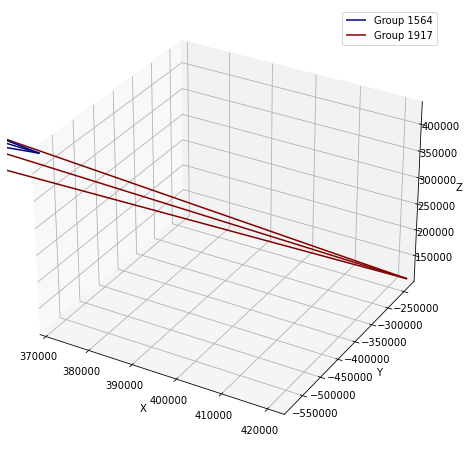

In [26]:
# Angular momentum calculations
Lg3 = snap6.calculate_angular_momentum((1564,1917))
print(Lg3)

# Plot angular momenta
snap6.plot_angular_momenta(Lg3)

### Group pair 4

Closest group IDs to specified points:  [155, 108]


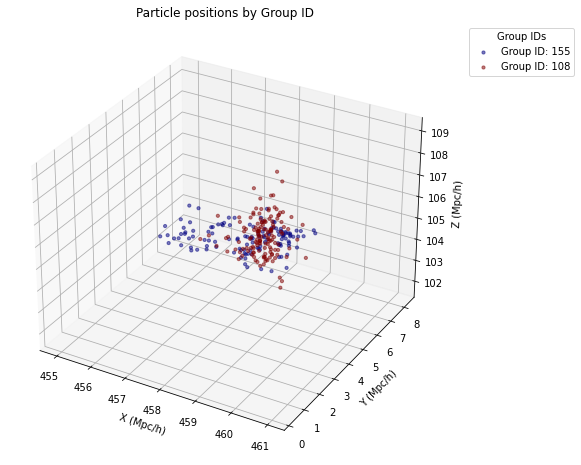

In [30]:
# Find group ID related to particles near a point of interest
points_of_interest = [(457, 6.95), (459.8,2.16)] # indicate points you want to search near as a tuple

# Get list of groups associated to the points we give
target_groups = snap6.find_closest_groups(points_of_interest=points_of_interest)
print("Closest group IDs to specified points: ", target_groups)

# Plot two halos of interest
snap6.plot_3D_particle_groups(target_ids=target_groups, legend=True)

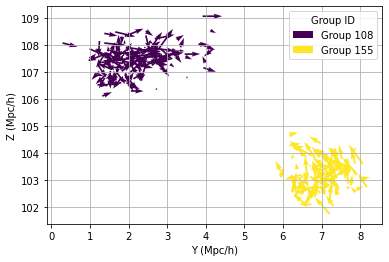

In [31]:
# Plot group velocities
snap6.plot_group_velocities(target_groups,scale=30000)

{108: array([-6877089.89911739, -6071838.79936277, 10558889.36202281]), 155: array([  1727641.74290985,   7008774.44451723, -14466976.00049896])}


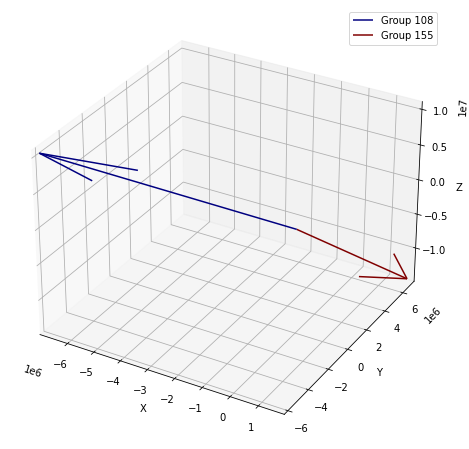

In [33]:
# Angular momentum calculations
Lg4 = snap6.calculate_angular_momentum((108,155))
print(Lg4)

# Plot angular momenta
snap6.plot_angular_momenta(Lg4)

### Group pair 5: 1$\sigma$ difference between number of particles (and third group nearby)

Closest group IDs to specified points:  [108, 528]


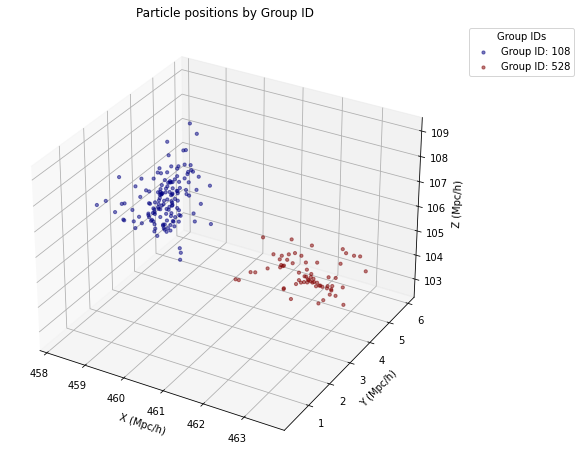

In [44]:
# Find group ID related to particles near a point of interest
points_of_interest = [(459, 2), (462,3.9)] # indicate points you want to search near as a tuple

# Get list of groups associated to the points we give
target_groups = snap6.find_closest_groups(points_of_interest=points_of_interest)
print("Closest group IDs to specified points: ", target_groups)

# Plot two halos of interest
snap6.plot_3D_particle_groups(target_ids=target_groups, legend=True)

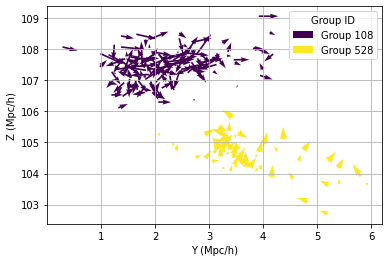

In [45]:
# Plot group velocities
snap6.plot_group_velocities(target_groups,scale=30000)

{108: array([-6877089.89911739, -6071838.79936277, 10558889.36202281]), 528: array([  531668.18055186, -1869769.89983479, -1952945.16543119])}


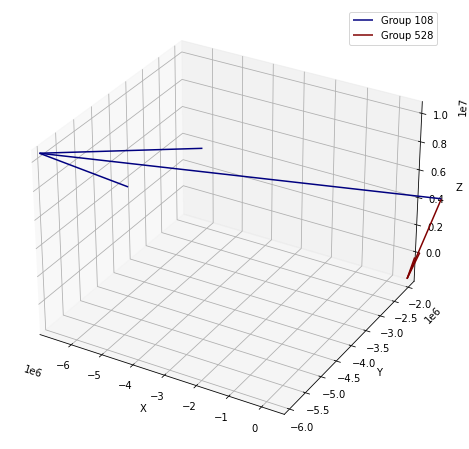

In [46]:
# Angular momentum calculations
Lg5 = snap6.calculate_angular_momentum((108,528))
print(Lg5)

# Plot angular momenta
snap6.plot_angular_momenta(Lg5)

### Group pair 6: Larger group above compared to group with more particles (both 1$\sigma$)

Closest group IDs to specified points:  [108, 155]


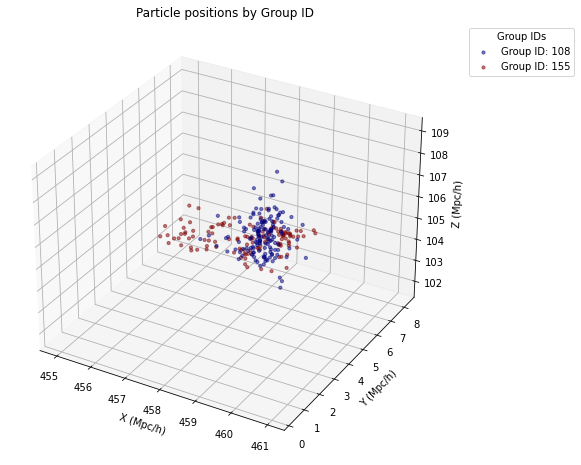

In [41]:
# Find group ID related to particles near a point of interest
points_of_interest = [(459, 2), (457,7.2)] # indicate points you want to search near as a tuple

# Get list of groups associated to the points we give
target_groups = snap6.find_closest_groups(points_of_interest=points_of_interest)
print("Closest group IDs to specified points: ", target_groups)

# Plot two halos of interest
snap6.plot_3D_particle_groups(target_ids=target_groups, legend=True)

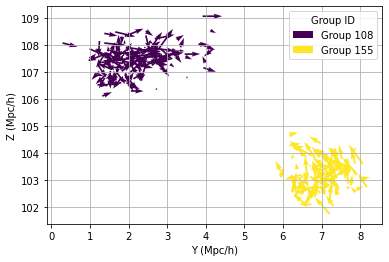

In [42]:
# Plot group velocities
snap6.plot_group_velocities(target_groups,scale=30000)

{108: array([-6877089.89911739, -6071838.79936277, 10558889.36202281]), 155: array([  1727641.74290985,   7008774.44451723, -14466976.00049896])}


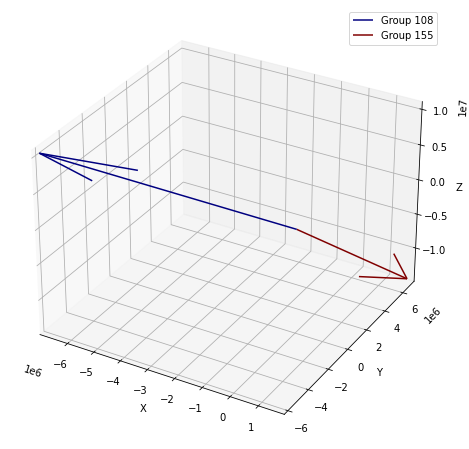

In [43]:
# Angular momentum calculations
Lg6 = snap6.calculate_angular_momentum((108,155))
print(Lg6)

# Plot angular momenta
snap6.plot_angular_momenta(Lg6)